In [1]:
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/sample_submission.csv
/kaggle/input/test.csv.zip
/kaggle/input/train.csv.zip
/kaggle/input/labels.csv.zip
/kaggle/input/train.csv
/kaggle/input/test.csv
/kaggle/input/labels.csv
/kaggle/input/description.md
/kaggle/input/GCP-Coupons-Instructions.rtf
/kaggle/input/sample_submission.csv.zip
/kaggle/input/new-york-city-taxi-fare-prediction/sample_submission.csv
/kaggle/input/new-york-city-taxi-fare-prediction/test.csv.zip
/kaggle/input/new-york-city-taxi-fare-prediction/train.csv.zip
/kaggle/input/new-york-city-taxi-fare-prediction/labels.csv.zip
/kaggle/input/new-york-city-taxi-fare-prediction/train.csv
/kaggle/input/new-york-city-taxi-fare-prediction/test.csv
/kaggle/input/new-york-city-taxi-fare-prediction/labels.csv
/kaggle/input/new-york-city-taxi-fare-prediction/description.md
/kaggle/input/new-york-city-taxi-fare-prediction/GCP-Coupons-Instructions.rtf
/kaggle/input/new-york-city-taxi-fare-prediction/sample_submission.csv.zip


In [2]:
train_data = pd.read_csv("/kaggle/input/train.csv", nrows=10_000_000)
train_data = train_data.set_index("key", drop=False)
train_data.head()



,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
key,,,,,,,,
2009-06-15 17:26:21.0000001,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
2010-01-05 16:52:16.0000002,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2011-08-18 00:35:00.00000049,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
2012-04-21 04:30:42.0000001,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
2010-03-09 07:51:00.000000135,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


In [3]:
train_data.shape



(10000000, 8)

In [4]:
train_data.info()



<class 'pandas.core.frame.DataFrame'>
Index: 10000000 entries, 2009-06-15 17:26:21.0000001 to 2010-03-30 19:27:00.00000066
Data columns (total 8 columns):
 #   Column             Dtype  
---  ------             -----  
 0   key                object 
 1   fare_amount        float64
 2   pickup_datetime    object 
 3   pickup_longitude   float64
 4   pickup_latitude    float64
 5   dropoff_longitude  float64
 6   dropoff_latitude   float64
 7   passenger_count    int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 686.6+ MB


In [5]:
test_data = pd.read_csv("/kaggle/input/test.csv")
test_data = test_data.set_index("key", drop=False)
test_data.head()



,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
key,,,,,,,
2010-10-01 21:26:11.0000001,2010-10-01 21:26:11.0000001,2010-10-01 21:26:11 UTC,-73.983130,40.761970,-73.994386,40.749236,1
2013-10-06 01:38:00.00000083,2013-10-06 01:38:00.00000083,2013-10-06 01:38:00 UTC,-73.948505,40.753977,-73.808195,40.731952,2
2012-03-30 19:13:53.0000001,2012-03-30 19:13:53.0000001,2012-03-30 19:13:53 UTC,-73.973964,40.791979,-73.979018,40.785544,1
2012-02-08 02:57:23.0000001,2012-02-08 02:57:23.0000001,2012-02-08 02:57:23 UTC,-73.991478,40.738907,-73.907198,40.861572,2
2013-12-13 22:56:00.000000237,2013-12-13 22:56:00.000000237,2013-12-13 22:56:00 UTC,-73.986281,40.740067,-73.933927,40.856781,2


In [6]:
test_data.info()



<class 'pandas.core.frame.DataFrame'>
Index: 9914 entries, 2010-10-01 21:26:11.0000001 to 2014-09-05 11:20:53.0000004
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                9914 non-null   object 
 1   pickup_datetime    9914 non-null   object 
 2   pickup_longitude   9914 non-null   float64
 3   pickup_latitude    9914 non-null   float64
 4   dropoff_longitude  9914 non-null   float64
 5   dropoff_latitude   9914 non-null   float64
 6   passenger_count    9914 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 619.6+ KB


In [7]:
train_data.isna().sum()



key                   0
fare_amount           0
pickup_datetime       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude    69
dropoff_latitude     69
passenger_count       0
dtype: int64

In [8]:
# Change (score-critical): do NOT take abs() here; sign carries directional signal for LinearRegression.
# Keeping the exact same feature concept ("difference") but fixing its computation for both train and test.
train_data["Difference_longitude"] = np.asarray(
    train_data["pickup_longitude"] - train_data["dropoff_longitude"]
)
train_data["Difference_latitude"] = np.asarray(
    train_data["pickup_latitude"] - train_data["dropoff_latitude"]
)

test_data["Difference_longitude"] = np.asarray(
    test_data["pickup_longitude"] - test_data["dropoff_longitude"]
)
test_data["Difference_latitude"] = np.asarray(
    test_data["pickup_latitude"] - test_data["dropoff_latitude"]
)



In [9]:
print(f"Before Dropping null values: {len(train_data)}")
train_data.dropna(inplace=True)
print(f"After Dropping null values: {len(train_data)}")



Before Dropping null values: 10000000
After Dropping null values: 9999931


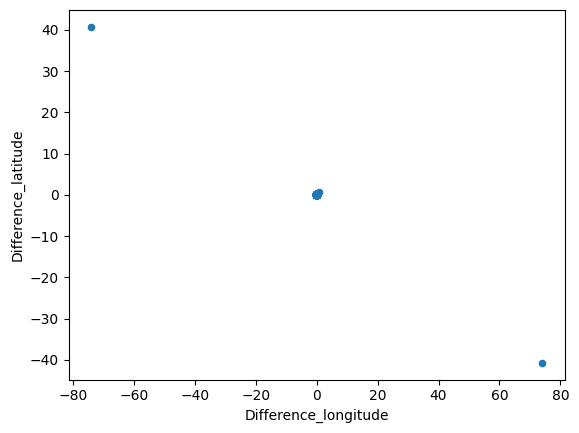

In [10]:
plot = train_data[:2000].plot.scatter("Difference_longitude", "Difference_latitude")



In [11]:
train_data = train_data[
    (train_data["Difference_longitude"] < 5.0)
    & (train_data["Difference_latitude"] < 5.0)
]



In [12]:
train_data = train_data[
    (train_data["fare_amount"] > 0) & (train_data["fare_amount"] <= 500)
]
train_data = train_data[
    (train_data["passenger_count"] >= 1) & (train_data["passenger_count"] <= 6)
]

train_data = train_data[
    (train_data["pickup_longitude"].between(-75, -72))
    & (train_data["dropoff_longitude"].between(-75, -72))
    & (train_data["pickup_latitude"].between(40, 42))
    & (train_data["dropoff_latitude"].between(40, 42))
]

train_data = train_data[
    (train_data["Difference_longitude"] > 0) | (train_data["Difference_latitude"] > 0)
]

train_data.shape



(6188151, 10)

In [13]:
train_dt = pd.to_datetime(train_data["pickup_datetime"], errors="coerce", utc=True)
test_dt = pd.to_datetime(test_data["pickup_datetime"], errors="coerce", utc=True)

train_data = train_data.loc[train_dt.notna()].copy()
train_dt = train_dt.loc[train_dt.notna()]

train_data["pickuptime"] = (train_dt.dt.hour * 60 + train_dt.dt.minute).astype(np.int32)
test_data["pickuptime"] = (
    test_dt.dt.hour.fillna(0).astype(int) * 60 + test_dt.dt.minute.fillna(0).astype(int)
).astype(np.int32)

train_data["Weekday"] = train_dt.dt.weekday.astype(np.int8)
test_data["Weekday"] = test_dt.dt.weekday.fillna(0).astype(int).astype(np.int8)



In [14]:
train_data.head()



,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Difference_longitude,Difference_latitude,pickuptime,Weekday
key,,,,,,,,,,,,
2009-06-15 17:26:21.0000001,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1,-0.002701,0.009041,1046,0
2011-08-18 00:35:00.00000049,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2,0.008504,0.010708,35,3
2012-04-21 04:30:42.0000001,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1,0.004437,-0.024949,270,5
2012-01-04 17:22:00.00000081,2012-01-04 17:22:00.00000081,16.5,2012-01-04 17:22:00 UTC,-73.951300,40.774138,-73.990095,40.751048,1,0.038795,0.023090,1042,2
2009-09-02 01:11:00.00000083,2009-09-02 01:11:00.00000083,8.9,2009-09-02 01:11:00 UTC,-73.980658,40.733873,-73.991540,40.758138,2,0.010882,-0.024265,71,2


In [15]:
train_data.head()



,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Difference_longitude,Difference_latitude,pickuptime,Weekday
key,,,,,,,,,,,,
2009-06-15 17:26:21.0000001,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1,-0.002701,0.009041,1046,0
2011-08-18 00:35:00.00000049,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2,0.008504,0.010708,35,3
2012-04-21 04:30:42.0000001,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1,0.004437,-0.024949,270,5
2012-01-04 17:22:00.00000081,2012-01-04 17:22:00.00000081,16.5,2012-01-04 17:22:00 UTC,-73.951300,40.774138,-73.990095,40.751048,1,0.038795,0.023090,1042,2
2009-09-02 01:11:00.00000083,2009-09-02 01:11:00.00000083,8.9,2009-09-02 01:11:00 UTC,-73.980658,40.733873,-73.991540,40.758138,2,0.010882,-0.024265,71,2


In [16]:
test_data.head()



,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Difference_longitude,Difference_latitude,pickuptime,Weekday
key,,,,,,,,,,,
2010-10-01 21:26:11.0000001,2010-10-01 21:26:11.0000001,2010-10-01 21:26:11 UTC,-73.983130,40.761970,-73.994386,40.749236,1,0.011256,0.012734,1286,4
2013-10-06 01:38:00.00000083,2013-10-06 01:38:00.00000083,2013-10-06 01:38:00 UTC,-73.948505,40.753977,-73.808195,40.731952,2,-0.140310,0.022025,98,6
2012-03-30 19:13:53.0000001,2012-03-30 19:13:53.0000001,2012-03-30 19:13:53 UTC,-73.973964,40.791979,-73.979018,40.785544,1,0.005054,0.006435,1153,4
2012-02-08 02:57:23.0000001,2012-02-08 02:57:23.0000001,2012-02-08 02:57:23 UTC,-73.991478,40.738907,-73.907198,40.861572,2,-0.084280,-0.122665,177,2
2013-12-13 22:56:00.000000237,2013-12-13 22:56:00.000000237,2013-12-13 22:56:00 UTC,-73.986281,40.740067,-73.933927,40.856781,2,-0.052354,-0.116714,1376,4


In [17]:
train_data.drop("pickup_datetime", inplace=True, axis=1)
test_data.drop("pickup_datetime", inplace=True, axis=1)



In [18]:
train_data["Weekday"].replace(
    to_replace=[i for i in range(0, 7)],
    value=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday",
    ],
    inplace=True,
)
test_data["Weekday"].replace(
    to_replace=[i for i in range(0, 7)],
    value=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday",
    ],
    inplace=True,
)



/tmp/ipykernel_11/2022498230.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data["Weekday"].replace(
/tmp/ipykernel_11/2022498230.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col

In [19]:
train_one_hot = pd.get_dummies(train_data["Weekday"])
test_one_hot = pd.get_dummies(test_data["Weekday"])
train_one_hot, test_one_hot = train_one_hot.align(
    test_one_hot, join="outer", axis=1, fill_value=0
)

train_data = pd.concat([train_data, train_one_hot], axis=1)
test_data = pd.concat([test_data, test_one_hot], axis=1)



In [20]:
train_data.drop("Weekday", axis=1, inplace=True)
test_data.drop("Weekday", axis=1, inplace=True)



In [21]:
train_data.head()



,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Difference_longitude,Difference_latitude,pickuptime,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
key,,,,,,,,,,,,,,,,,
2009-06-15 17:26:21.0000001,2009-06-15 17:26:21.0000001,4.5,-73.844311,40.721319,-73.841610,40.712278,1,-0.002701,0.009041,1046,False,True,False,False,False,False,False
2011-08-18 00:35:00.00000049,2011-08-18 00:35:00.00000049,5.7,-73.982738,40.761270,-73.991242,40.750562,2,0.008504,0.010708,35,False,False,False,False,True,False,False
2012-04-21 04:30:42.0000001,2012-04-21 04:30:42.0000001,7.7,-73.987130,40.733143,-73.991567,40.758092,1,0.004437,-0.024949,270,False,False,True,False,False,False,False
2012-01-04 17:22:00.00000081,2012-01-04 17:22:00.00000081,16.5,-73.951300,40.774138,-73.990095,40.751048,1,0.038795,0.023090,1042,False,False,False,False,False,False,True
2009-09-02 01:11:00.00000083,2009-09-02 01:11:00.00000083,8.9,-73.980658,40.733873,-73.991540,40.758138,2,0.010882,-0.024265,71,False,False,False,False,False,False,True


In [22]:
R = 6373.0
lat1 = np.asarray(np.radians(train_data["pickup_latitude"]))
lon1 = np.asarray(np.radians(train_data["pickup_longitude"]))
lat2 = np.asarray(np.radians(train_data["dropoff_latitude"]))
lon2 = np.asarray(np.radians(train_data["dropoff_longitude"]))

dlon = lon2 - lon1
dlat = lat2 - lat1
a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
distance = R * c
train_data["Distance"] = np.asarray(distance) * 0.621

lat1 = np.asarray(np.radians(test_data["pickup_latitude"]))
lon1 = np.asarray(np.radians(test_data["pickup_longitude"]))
lat2 = np.asarray(np.radians(test_data["dropoff_latitude"]))
lon2 = np.asarray(np.radians(test_data["dropoff_longitude"]))

dlon = lon2 - lon1
dlat = lat2 - lat1
a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
distance = R * c
test_data["Distance"] = np.asarray(distance) * 0.621



In [23]:
R = 6373.0
lat1 = np.asarray(np.radians(train_data["pickup_latitude"]))
lon1 = np.asarray(np.radians(train_data["pickup_longitude"]))
lat2 = np.asarray(np.radians(train_data["dropoff_latitude"]))
lon2 = np.asarray(np.radians(train_data["dropoff_longitude"]))

lat3 = np.zeros(len(train_data)) + np.radians(40.6413111)
lon3 = np.zeros(len(train_data)) + np.radians(-73.7781391)

dlon_pickup = lon3 - lon1
dlat_pickup = lat3 - lat1
d_lon_dropoff = lon3 - lon2
d_lat_dropoff = lat3 - lat2

a1 = (
    np.sin(dlat_pickup / 2) ** 2
    + np.cos(lat1) * np.cos(lat3) * np.sin(dlon_pickup / 2) ** 2
)
c1 = 2 * np.arctan2(np.sqrt(a1), np.sqrt(1 - a1))
distance1 = R * c1
train_data["Pickup_Distance_airport"] = np.asarray(distance1) * 0.621

a2 = (
    np.sin(d_lat_dropoff / 2) ** 2
    + np.cos(lat2) * np.cos(lat3) * np.sin(d_lon_dropoff / 2) ** 2
)
c2 = 2 * np.arctan2(np.sqrt(a2), np.sqrt(1 - a2))
distance2 = R * c2
train_data["Dropoff_Distance_airport"] = np.asarray(distance2) * 0.621

lat1 = np.asarray(np.radians(test_data["pickup_latitude"]))
lon1 = np.asarray(np.radians(test_data["pickup_longitude"]))
lat2 = np.asarray(np.radians(test_data["dropoff_latitude"]))
lon2 = np.asarray(np.radians(test_data["dropoff_longitude"]))

lat3 = np.zeros(len(test_data)) + np.radians(40.6413111)
lon3 = np.zeros(len(test_data)) + np.radians(-73.7781391)

dlon_pickup = lon3 - lon1
dlat_pickup = lat3 - lat1
d_lon_dropoff = lon3 - lon2
d_lat_dropoff = lat3 - lat2

a1 = (
    np.sin(dlat_pickup / 2) ** 2
    + np.cos(lat1) * np.cos(lat3) * np.sin(dlon_pickup / 2) ** 2
)
c1 = 2 * np.arctan2(np.sqrt(a1), np.sqrt(1 - a1))
distance1 = R * c1
test_data["Pickup_Distance_airport"] = np.asarray(distance1) * 0.621

a2 = (
    np.sin(d_lat_dropoff / 2) ** 2
    + np.cos(lat2) * np.cos(lat3) * np.sin(d_lon_dropoff / 2) ** 2
)
c2 = 2 * np.arctan2(np.sqrt(a2), np.sqrt(1 - a2))
distance2 = R * c2
test_data["Dropoff_Distance_airport"] = np.asarray(distance2) * 0.621



In [24]:
train_data["Distance"] = np.round(train_data["Distance"], 2)
train_data["Pickup_Distance_airport"] = np.round(
    train_data["Pickup_Distance_airport"], 2
)
train_data["Dropoff_Distance_airport"] = np.round(
    train_data["Dropoff_Distance_airport"], 2
)

test_data["Distance"] = np.round(test_data["Distance"], 2)
test_data["Pickup_Distance_airport"] = np.round(test_data["Pickup_Distance_airport"], 2)
test_data["Dropoff_Distance_airport"] = np.round(
    test_data["Dropoff_Distance_airport"], 2
)



In [25]:
dist_cols = ["Distance", "Pickup_Distance_airport", "Dropoff_Distance_airport"]
train_data[dist_cols] = (
    train_data[dist_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
)
test_data[dist_cols] = (
    test_data[dist_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
)



In [26]:
train_data.drop(
    ["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude"],
    axis=1,
    inplace=True,
)
test_data.drop(
    ["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude"],
    axis=1,
    inplace=True,
)



In [27]:
dl_mean = float(np.mean(train_data["Difference_longitude"]))
dl_std = float(np.std(train_data["Difference_longitude"]))
dlat_mean = float(np.mean(train_data["Difference_latitude"]))
dlat_std = float(np.std(train_data["Difference_latitude"]))

if dl_std == 0.0:
    dl_std = 1.0
if dlat_std == 0.0:
    dlat_std = 1.0

train_data["Difference_longitude"] = (
    train_data["Difference_longitude"] - dl_mean
) / dl_std
train_data["Difference_latitude"] = (
    train_data["Difference_latitude"] - dlat_mean
) / dlat_std

test_data["Difference_longitude"] = (
    test_data["Difference_longitude"] - dl_mean
) / dl_std
test_data["Difference_latitude"] = (
    test_data["Difference_latitude"] - dlat_mean
) / dlat_std



In [28]:
train_data.shape



(6188151, 16)

In [29]:
test_data.shape



(9914, 15)

In [30]:
from sklearn.model_selection import train_test_split

train_data = train_data[
    (train_data["fare_amount"] > 0.0) & (train_data["fare_amount"] <= 500.0)
].copy()

X = train_data.drop(["key", "fare_amount"], axis=1)
y = train_data["fare_amount"]

test_keys_in_order = test_data.index.astype(str).values
test_features = test_data.drop("key", axis=1).copy()
test_features = test_features.reindex(index=test_data.index)

test_features = test_features.reindex(columns=X.columns, fill_value=0.0)

X = X.apply(pd.to_numeric, errors="coerce")
test_features = test_features.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

X = X.replace([np.inf, -np.inf], np.nan)
test_features = test_features.replace([np.inf, -np.inf], np.nan)

finite_mask = np.isfinite(X.to_numpy(dtype=np.float64)).all(axis=1) & np.isfinite(
    y.to_numpy(dtype=np.float64)
)
X = X.loc[finite_mask].copy()
y = y.loc[finite_mask].copy()

X = X.fillna(0.0)
test_features = test_features.fillna(0.0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.01, random_state=80
)

assert test_features.shape[0] == len(
    test_keys_in_order
), "Test rows changed during feature prep."
assert np.all(
    test_features.index.astype(str).values == test_keys_in_order
), "Test feature row order != test key order."



In [31]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
print(lr.score(X_test, y_test))



0.6989130742767087


In [32]:
pred = lr.predict(test_features)

pred = np.clip(pred, 0.0, None)
pred = np.round(pred, 2)

assert pred.shape[0] == len(
    test_keys_in_order
), "Pred length != test rows; would cause misaligned submission."



In [33]:
pd.read_csv("/kaggle/input/sample_submission.csv").head()



,key,fare_amount
0,2010-10-01 21:26:11.0000001,11.35
1,2013-10-06 01:38:00.00000083,11.35
2,2012-03-30 19:13:53.0000001,11.35
3,2012-02-08 02:57:23.0000001,11.35
4,2013-12-13 22:56:00.000000237,11.35


In [34]:
Submission = pd.DataFrame({"key": test_keys_in_order, "fare_amount": pred})
Submission = Submission[["key", "fare_amount"]]

sample = pd.read_csv("/kaggle/input/sample_submission.csv")
assert (
    Submission.shape[0] == sample.shape[0]
), "Row count mismatch vs sample submission."
assert np.all(
    Submission["key"].values == sample["key"].astype(str).values
), "Submission keys/order mismatch vs sample_submission."

Submission.head()



,key,fare_amount
0,2010-10-01 21:26:11.0000001,8.04
1,2013-10-06 01:38:00.00000083,33.05
2,2012-03-30 19:13:53.0000001,5.76
3,2012-02-08 02:57:23.0000001,44.02
4,2013-12-13 22:56:00.000000237,39.17


In [35]:
Submission.to_csv("Submission.csv", index=False)
print("Wrote submission file:", os.path.abspath("Submission.csv"))
print(Submission.shape)
print(Submission.head())

Wrote submission file: /kaggle/working/Submission.csv
(9914, 2)
                             key  fare_amount
0    2010-10-01 21:26:11.0000001         8.04
1   2013-10-06 01:38:00.00000083        33.05
2    2012-03-30 19:13:53.0000001         5.76
3    2012-02-08 02:57:23.0000001        44.02
4  2013-12-13 22:56:00.000000237        39.17
